In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/PEDE_PASSOS_DATASET_FIAP.csv', sep=';', encoding='utf-8')

In [3]:
df.shape

(1349, 69)

In [4]:
df.columns

Index(['INSTITUICAO_ENSINO_ALUNO_2020', 'NOME', 'IDADE_ALUNO_2020',
       'ANOS_PM_2020', 'FASE_TURMA_2020', 'PONTO_VIRADA_2020', 'INDE_2020',
       'INDE_CONCEITO_2020', 'PEDRA_2020', 'DESTAQUE_IEG_2020',
       'DESTAQUE_IDA_2020', 'DESTAQUE_IPV_2020', 'IAA_2020', 'IEG_2020',
       'IPS_2020', 'IDA_2020', 'IPP_2020', 'IPV_2020', 'IAN_2020', 'FASE_2021',
       'TURMA_2021', 'INSTITUICAO_ENSINO_ALUNO_2021',
       'SINALIZADOR_INGRESSANTE_2021', 'PEDRA_2021', 'INDE_2021', 'IAA_2021',
       'IEG_2021', 'IPS_2021', 'IDA_2021', 'IPP_2021', 'REC_EQUIPE_1_2021',
       'REC_EQUIPE_2_2021', 'REC_EQUIPE_3_2021', 'REC_EQUIPE_4_2021',
       'PONTO_VIRADA_2021', 'IPV_2021', 'IAN_2021', 'NIVEL_IDEAL_2021',
       'DEFASAGEM_2021', 'FASE_2022', 'TURMA_2022', 'ANO_INGRESSO_2022',
       'BOLSISTA_2022', 'INDE_2022', 'CG_2022', 'CF_2022', 'CT_2022',
       'PEDRA_2022', 'DESTAQUE_IEG_2022', 'DESTAQUE_IDA_2022',
       'DESTAQUE_IPV_2022', 'IAA_2022', 'IEG_2022', 'IPS_2022', 'IDA_2022',
       

In [5]:
df.iloc[[1258]]

,INSTITUICAO_ENSINO_ALUNO_2020,NOME,IDADE_ALUNO_2020,ANOS_PM_2020,FASE_TURMA_2020,PONTO_VIRADA_2020,INDE_2020,INDE_CONCEITO_2020,PEDRA_2020,DESTAQUE_IEG_2020,...,IPP_2022,REC_AVA_1_2022,REC_AVA_2_2022,REC_AVA_3_2022,REC_AVA_4_2022,INDICADO_BOLSA_2022,PONTO_VIRADA_2022,IPV_2022,IAN_2022,NIVEL_IDEAL_2022
1258,V202,ALUNO-1259,D108,D971,D207,D9600,D980,D9891/2,D9891/2A,D301,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df = df.drop([1258], axis=0).reset_index(drop=True)

In [7]:
df.head()

,INSTITUICAO_ENSINO_ALUNO_2020,NOME,IDADE_ALUNO_2020,ANOS_PM_2020,FASE_TURMA_2020,PONTO_VIRADA_2020,INDE_2020,INDE_CONCEITO_2020,PEDRA_2020,DESTAQUE_IEG_2020,...,IPP_2022,REC_AVA_1_2022,REC_AVA_2_2022,REC_AVA_3_2022,REC_AVA_4_2022,INDICADO_BOLSA_2022,PONTO_VIRADA_2022,IPV_2022,IAN_2022,NIVEL_IDEAL_2022
0,Escola Pública,ALUNO-1,11,2,2H,Não,7.883752,B,Ametista,Seu destaque em 2020: A sua boa entrega das li...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,ALUNO-2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.625000,Mantido na Fase + Bolsa,Mantido na Fase atual,NaN,NaN,Sim,Não,7.916665,5.0,Fase 2 (5º e 6º ano)
2,Escola Pública,ALUNO-3,12,2,3H,Não,7.856389666666666,B,Ametista,Seu destaque em 2020: A sua boa entrega das li...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Escola Pública,ALUNO-4,10,2,1D,Não,5.076252,D,Quartzo,Ponto a melhorar em 2021: Melhorar a sua entre...,...,6.250000,Promovido de Fase,Mantido na Fase atual,Promovido de Fase,NaN,Não,Não,8.055553,5.0,Fase 3 (7º e 8º ano)
4,Escola Pública,ALUNO-5,10,1,2M,Não,8.077085,B,Ametista,Seu destaque em 2020: A sua boa entrega das li...,...,6.458333,Mantido na Fase atual,Promovido de Fase,Mantido na Fase atual,NaN,Não,Não,7.833337,5.0,Fase 3 (7º e 8º ano)


In [8]:
cols = ['IAN_2020', 'IDA_2020', 'IEG_2020','IAA_2020', 'IPS_2020', 'IPP_2020', 'IPV_2020', 'INDE_2020',
        'IAN_2021', 'IDA_2021', 'IEG_2021','IAA_2021', 'IPS_2021', 'IPP_2021', 'IPV_2021', 'INDE_2021',
        'IAN_2022', 'IDA_2022', 'IEG_2022','IAA_2022', 'IPS_2022', 'IPP_2022', 'IPV_2022', 'INDE_2022']

df.replace('#NULO!', None, inplace=True)

df[cols] = df[cols].astype(float)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1348 entries, 0 to 1347
Data columns (total 69 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   INSTITUICAO_ENSINO_ALUNO_2020  727 non-null    object 
 1   NOME                           1348 non-null   object 
 2   IDADE_ALUNO_2020               727 non-null    object 
 3   ANOS_PM_2020                   727 non-null    object 
 4   FASE_TURMA_2020                727 non-null    object 
 5   PONTO_VIRADA_2020              701 non-null    object 
 6   INDE_2020                      727 non-null    float64
 7   INDE_CONCEITO_2020             727 non-null    object 
 8   PEDRA_2020                     727 non-null    object 
 9   DESTAQUE_IEG_2020              727 non-null    object 
 10  DESTAQUE_IDA_2020              727 non-null    object 
 11  DESTAQUE_IPV_2020              703 non-null    object 
 12  IAA_2020                       727 non-null    f

In [10]:
df_2020 = df[['IAN_2020',
              'IDA_2020',
              'IEG_2020',
              'IAA_2020',
              'IPS_2020',
              'IPP_2020',
              'IPV_2020',
              'INDE_2020']]

df_2021 = df[['IAN_2021',
              'IDA_2021',
              'IEG_2021',
              'IAA_2021',
              'IPS_2021',
              'IPP_2021',
              'IPV_2021',
              'INDE_2021']]

df_2022 = df[['IAN_2022',
              'IDA_2022',
              'IEG_2022',
              'IAA_2022',
              'IPS_2022',
              'IPP_2022',
              'IPV_2022',
              'INDE_2022']]

In [11]:
def rename_columns(df, ano):
    df.rename(columns={f'IAN_{ano}': 'IAN',
                       f'IDA_{ano}': 'IDA',
                       f'IEG_{ano}': 'IEG',
                       f'IAA_{ano}': 'IAA',
                       f'IPS_{ano}': 'IPS',
                       f'IPP_{ano}': 'IPP',
                       f'IPV_{ano}': 'IPV',
                       f'INDE_{ano}': 'INDE'}, inplace=True)

In [12]:
rename_columns(df_2020, '2020')
rename_columns(df_2021, '2021')
rename_columns(df_2022, '2022')

In [13]:
df_2020['Ano'] = '2020'
df_2021['Ano'] = '2021'
df_2022['Ano'] = '2022'

In [14]:
df_indicadores = pd.concat([df_2020, df_2021, df_2022], axis=0, ignore_index=True)

In [15]:
df_indicadores

,IAN,IDA,IEG,IAA,IPS,IPP,IPV,INDE,Ano
0,10.0,7.0,8.700000,8.50002,7.500,5.93750,7.750000,7.883752,2020
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020
2,10.0,5.5,8.900000,7.91667,7.500,8.12500,8.111113,7.856390,2020
3,5.0,0.0,4.100000,8.00002,6.875,7.18750,7.750000,5.076252,2020
4,10.0,7.5,8.000000,7.50002,7.500,8.43750,8.166665,8.077085,2020
...,...,...,...,...,...,...,...,...,...
4039,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022
4040,5.0,9.0,9.031839,9.00002,7.500,5.62500,9.083340,8.135538,2022
4041,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022
4042,5.0,5.9,9.178030,8.33334,5.625,6.71875,5.833328,6.749981,2022


In [16]:
df.describe()

,INDE_2020,IAA_2020,IEG_2020,IPS_2020,IDA_2020,IPP_2020,IPV_2020,IAN_2020,FASE_2021,INDE_2021,...,IEG_2022,IPS_2022,IDA_2022,NOTA_PORT_2022,NOTA_MAT_2022,NOTA_ING_2022,QTD_AVAL_2022,IPP_2022,IPV_2022,IAN_2022
count,727.000000,727.000000,727.000000,727.000000,727.000000,727.000000,727.000000,727.000000,686.000000,684.000000,...,862.000000,862.000000,862.000000,860.000000,860.000000,285.000000,862.000000,862.000000,862.000000,862.000000
mean,7.296111,8.368882,7.681155,6.737448,6.322260,7.067859,7.242243,7.431224,2.276968,6.888016,...,7.880728,6.901102,6.070688,5.796318,6.306628,5.839942,3.056845,6.299364,7.247953,6.421114
std,1.199925,1.727980,2.382122,1.374011,2.960073,1.988054,1.775110,2.556944,1.798368,1.354180,...,1.649023,1.070202,2.059346,2.422292,2.092551,2.992093,0.775806,1.135510,1.098548,2.387816
min,3.065001,0.000000,0.000000,2.500000,0.000000,0.000000,0.000000,2.500000,0.000000,2.468000,...,0.000000,2.500000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,2.500010,2.500000
25%,6.569584,7.958350,6.600000,5.625000,4.666667,6.953125,6.916665,5.000000,1.000000,6.066250,...,6.999971,6.250000,4.750000,4.316667,5.166667,3.500000,2.000000,5.625000,6.722220,5.000000
50%,7.580834,8.750010,8.500000,7.500000,7.000000,7.500000,7.583335,5.000000,2.000000,7.166000,...,8.312179,7.500000,6.333333,6.000000,6.650000,6.266667,3.000000,6.250000,7.333335,5.000000
75%,8.178960,9.166680,9.500000,7.500000,8.666667,8.125000,8.055557,10.000000,3.000000,7.892750,...,9.102970,7.500000,7.583333,7.833333,7.833333,8.500000,4.000000,7.031250,7.916665,10.000000
max,9.712504,10.000020,10.000000,10.000000,10.000000,10.000000,10.000010,10.000000,7.000000,9.294000,...,10.000000,10.000000,9.916667,10.000000,10.000000,10.000000,4.000000,9.218750,10.000010,10.000000


### **1. Adequação do nível (IAN): Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?**

In [17]:
IAN_anos = df_indicadores[['Ano', 'IAN']]

In [18]:
IAN_anos['IAN'].replace({10.0: 'Em fase', 5.0: 'Moderada', 2.5: 'Severa'}, inplace=True)

In [19]:
IAN_anos = IAN_anos.groupby('Ano').value_counts().reset_index().sort_values(by=['Ano', 'IAN'])

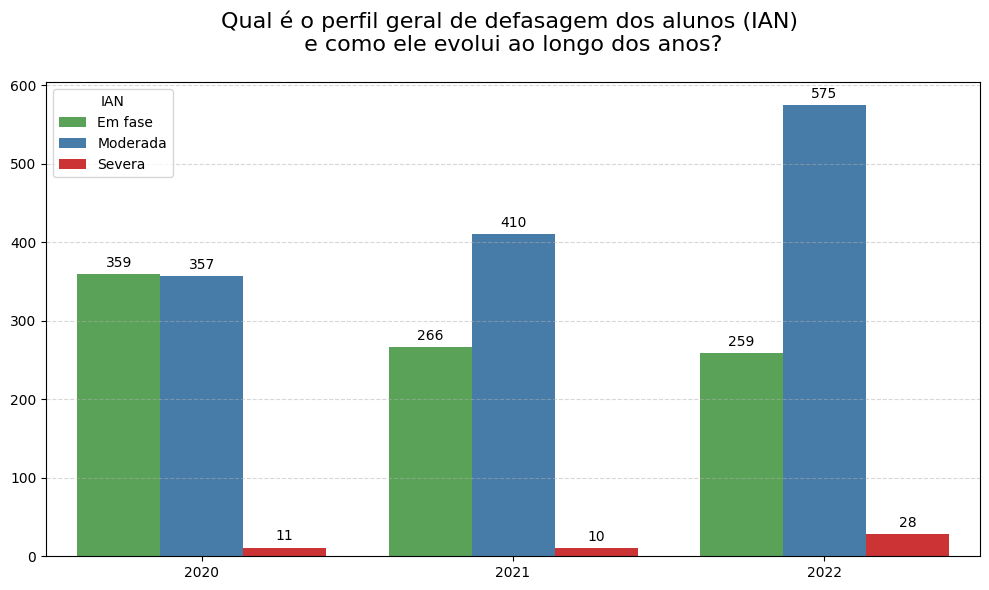

In [20]:
cores_set1 = sns.color_palette('Set1', n_colors=9)

cores_personalizadas = cores_set1[2::-1] + cores_set1[3:]

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='Ano',
    y='count',
    hue='IAN',
    data=IAN_anos,
    palette=cores_personalizadas
)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Qual é o perfil geral de defasagem dos alunos (IAN) \n e como ele evolui ao longo dos anos? \n', fontsize=16)
plt.xlabel(None)
plt.ylabel(None)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Com base nos dados apresentados, o perfil de defasagem dos alunos (IAN) demonstra uma deterioração progressiva entre 2020 e 2022. Enquanto em 2020 havia um equilíbrio entre alunos "Em fase" (359) e com defasagem "Moderada" (357), os anos seguintes mostram uma queda acentuada no grupo que está no nível adequado, reduzindo-se para 259 alunos em 2022. Em contrapartida, a defasagem Moderada tornou-se predominante, saltando de 357 para 575 alunos no período. Além disso, embora a defasagem "Severa" tenha se mantido baixa e estável nos dois primeiros anos, houve um aumento preocupante de 180% nessa categoria em 2022 (passando de 10 para 28 alunos), indicando que o desafio educacional se intensificou tanto em volume quanto em gravidade ao longo do tempo.

In [21]:
total_anos = IAN_anos.groupby('Ano')['count'].sum()

In [22]:
IAN_anos = IAN_anos.merge(total_anos, on='Ano', how='left', suffixes=('', '_total'))

In [23]:
IAN_anos['pct_change'] = (IAN_anos.groupby('IAN')['count'].pct_change() * 100).round(2)

In [24]:
IAN_anos['prop_ano'] = IAN_anos['count'] / IAN_anos['count_total']

prop_Ano é a fração que cada IAN representa do total daquele Ano, garantindo comparabilidade mesmo se o total anual mudar.

In [25]:
IAN_anos['pct_change_prop'] = (IAN_anos.groupby('IAN')['prop_ano'].pct_change() * 100).round(2)

In [26]:
IAN_anos['diff_anual'] = IAN_anos.groupby('IAN')['count'].diff()

In [27]:
IAN_anos[['Ano', 'IAN', 'count', 'pct_change', 'pct_change_prop', 'diff_anual']].set_index('Ano')

,IAN,count,pct_change,pct_change_prop,diff_anual
Ano,,,,,
2020,Em fase,359,NaN,NaN,NaN
2020,Moderada,357,NaN,NaN,NaN
2020,Severa,11,NaN,NaN,NaN
2021,Em fase,266,-25.91,-21.48,-93.0
2021,Moderada,410,14.85,21.71,53.0
2021,Severa,10,-9.09,-3.66,-1.0
2022,Em fase,259,-2.63,-22.51,-7.0
2022,Moderada,575,40.24,11.61,165.0
2022,Severa,28,180.00,122.83,18.0


### **2. Desempenho acadêmico (IDA): O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?**

Média do IDA ao longo dos anos

In [28]:
df_indicadores[['IDA', 'Ano']].groupby(by='Ano').mean().round(3)

,IDA
Ano,
2020,6.322
2021,5.426
2022,6.071


Diferença das médias ao longo dos anos

In [29]:
df_indicadores[['IDA', 'Ano']].groupby('Ano').mean().diff().round(3)

,IDA
Ano,
2020,NaN
2021,-0.896
2022,0.645


Porcentagem da diferença ao longo dos anos

In [30]:
(df_indicadores[['IDA', 'Ano']].groupby('Ano').mean().pct_change() * 100).round(2)

,IDA
Ano,
2020,NaN
2021,-14.18
2022,11.88


Média central

In [31]:
df_indicadores['IDA'].mean().round(3)

np.float64(5.957)

Desvio Padrão da média central

In [32]:
df_indicadores[['IDA', 'Ano']].groupby('Ano').mean().std().round(3)

IDA    0.462
dtype: float64

### **3. Engajamento nas atividades (IEG): O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?**

Correlação IEG x IDA

In [33]:
(df_indicadores['IEG'].corr(df_indicadores['IDA']) * 100).round(2)

np.float64(56.48)

Correlação IEG x IPV

In [34]:
(df_indicadores['IEG'].corr(df_indicadores['IPV']) * 100).round(2)

np.float64(51.99)

In [35]:
import statsmodels.api as sm

def resumo_executivo_regressao(df, dependente):
    # Limpeza e Modelagem
    df_limpo = df[['IEG', dependente]].dropna()
    X = sm.add_constant(df_limpo['IEG'])
    y = df_limpo[dependente]
    modelo = sm.OLS(y, X).fit()
    
    # Extração dos indicadores-chave
    r2 = modelo.rsquared
    coef_ieg = modelo.params['IEG']
    p_value = modelo.pvalues['IEG']
    intercepto = modelo.params['const']
    
    # Impressão formatada para interpretação
    print(f"--- ANÁLISE EXECUTIVA: IEG vs {dependente} ---")
    print(f"1. PODER DE EXPLICAÇÃO (R²): {r2:.2%}")
    print(f"   O engajamento explica {r2:.2%} da variação de {dependente}.")
    
    print(f"\n2. IMPACTO (Coeficiente): {coef_ieg:.4f}")
    print(f"   Cada +1 ponto em IEG resulta em uma mudança de {coef_ieg:.4f} em {dependente}.")
    
    status_p = "SIGNIFICATIVA" if p_value < 0.05 else "NÃO SIGNIFICATIVA"
    print(f"\n3. CONFIANÇA ESTATÍSTICA (P-Value): {p_value:.4f} ({status_p})")
    
    print(f"\n4. EQUAÇÃO PREDITIVA:")
    print(f"   {dependente} = {intercepto:.2f} + ({coef_ieg:.2f} * IEG)")
    print("-" * 45 + "\n")

In [36]:
resumo_executivo_regressao(df_indicadores, 'IDA')

--- ANÁLISE EXECUTIVA: IEG vs IDA ---
1. PODER DE EXPLICAÇÃO (R²): 31.90%
   O engajamento explica 31.90% da variação de IDA.

2. IMPACTO (Coeficiente): 0.6228
   Cada +1 ponto em IEG resulta em uma mudança de 0.6228 em IDA.

3. CONFIANÇA ESTATÍSTICA (P-Value): 0.0000 (SIGNIFICATIVA)

4. EQUAÇÃO PREDITIVA:
   IDA = 1.29 + (0.62 * IEG)
---------------------------------------------



**Sim, existe uma relação direta, positiva e estatisticamente comprovada.**  
O engajamento dos alunos (IEG) é um motor fundamental para o desempenho acadêmico (IDA). A análise revela que a relação entre essas variáveis não é fruto do acaso, apresentando uma confiança estatística total ($p < 0,001$).

**Relação de Causa e Efeito:**  
- O engajamento atua como um preditor direto da nota. Para cada ponto que um aluno sobe em sua escala de engajamento, espera-se um aumento médio de 0,62 em seu indicador de desempenho (IDA).  
  
- Peso do Engajamento: O IEG sozinho consegue explicar quase 32% de tudo o que acontece com as notas dos alunos. Isso significa que, em um cenário escolar complexo, quase um terço do sucesso acadêmico pode ser atribuído diretamente ao nível de participação e dedicação do estudante.  
  
- Consistência Pedagógica: A equação preditiva ($IDA = 1,29 + 0,62 \times IEG$) mostra que o engajamento "potencializa" o desempenho. Mesmo alunos que partem de uma base comum (o intercepto de 1,29) dependem do crescimento do IEG para atingir patamares de aprovação e excelência.Conclusão: O investimento em estratégias para elevar o engajamento terá um retorno mensurável e direto na melhora dos indicadores de desempenho da instituição.

In [37]:
resumo_executivo_regressao(df_indicadores, 'IPV')

--- ANÁLISE EXECUTIVA: IEG vs IPV ---
1. PODER DE EXPLICAÇÃO (R²): 27.03%
   O engajamento explica 27.03% da variação de IPV.

2. IMPACTO (Coeficiente): 0.3548
   Cada +1 ponto em IEG resulta em uma mudança de 0.3548 em IPV.

3. CONFIANÇA ESTATÍSTICA (P-Value): 0.0000 (SIGNIFICATIVA)

4. EQUAÇÃO PREDITIVA:
   IPV = 4.63 + (0.35 * IEG)
---------------------------------------------



| Métrica                     | IDA (Desempenho Acadêmico) | IPV (Ponto de Virada) |
|----------------------------|---------------------------|-----------------------|
| Poder de Explicação (R²)   | 31,90%                    | 27,03%                |
| Impacto Direto (Coeficiente)| 0,6228                    | 0,3548                |
| Ponto de Partida (Intercepto) | 1,29                   | 4,63                  |
| Confiança (P-Value)        | 0,0000 (Significativo)    | 0,0000 (Significativo)|
| Equação Preditiva          | IDA = 1,29 + 0,62 × IEG   | IPV = 4,63 + 0,35 × IEG |


**Interpretação da Comparação**  
- O IDA é mais "sensível" ao engajamento: O coeficiente do IDA ($0,62$) é quase o dobro do IPV ($0,35$). Isso indica que o esforço e engajamento do aluno se refletem de forma muito mais imediata e intensa nas notas do que na mudança de sua trajetória de longo prazo.  
  
- O IPV tem uma base mais estável: Note que o ponto de partida do IPV ($4,63$) é muito mais alto que o do IDA ($1,29$). Isso sugere que o "Ponto de Virada" depende de uma base socioeducacional mais sólida, enquanto o desempenho nas notas é mais volátil e dependente do engajamento presente.  
  
- Explicação de Variância: O engajamento explica melhor o desempenho atual ($31,9\%$) do que a virada de trajetória ($27\%$). Isso faz sentido pedagógico: "virar a chave" (IPV) é um processo mais complexo que envolve fatores além do engajamento, como resiliência e suporte externo.

### **4. Autoavaliação (IAA): As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?**

#### Correlação IAA x IDA

In [38]:
(df_indicadores['IAA'].corr(df_indicadores['IDA']) * 100).round(2)

np.float64(26.49)

#### Correlação IAA x IEG

In [39]:
(df_indicadores['IAA'].corr(df_indicadores['IEG']) * 100).round(2)

np.float64(32.74)

In [40]:
def plot_quadrantes(x_col, y_col, df):
    plt.figure(figsize=(11, 6))
    
    sns.scatterplot(data=df, x=x_col, y=y_col, alpha=0.6, s=100)
    
    # Linhas de média para criar os quadrantes
    mean_x = df[x_col].mean()
    mean_y = df[y_col].mean()
    plt.axvline(mean_x, color='red', linestyle='-', alpha=0.8)
    plt.axhline(mean_y, color='red', linestyle='-', alpha=0.8)
    
    # Títulos e labels
    plt.title(f'Análise de Coerência: {x_col} vs {y_col}', fontsize=14, pad=20)
    plt.xlabel(f'{x_col} (Percepção)', fontsize=12)
    plt.ylabel(f'{y_col} (Realidade)', fontsize=12)
    
    # Lado Direito
    plt.text(1.02, 0.95, 'Coerentes (Alto)', color='green', transform=plt.gca().transAxes, va='top')
    plt.text(1.02, 0.05, 'Superestimados', color='red', transform=plt.gca().transAxes, va='bottom')
    
    # Lado Esquerdo
    plt.text(-0.20, 0.95, 'Subestimados', color='red', transform=plt.gca().transAxes, va='top')
    plt.text(-0.20, 0.05, 'Coerentes (Baixo)', color='green', transform=plt.gca().transAxes, va='bottom')
    
    plt.grid(True, alpha=0.3)
    
    plt.subplots_adjust(right=0.85, left=0.20) 
    plt.show()

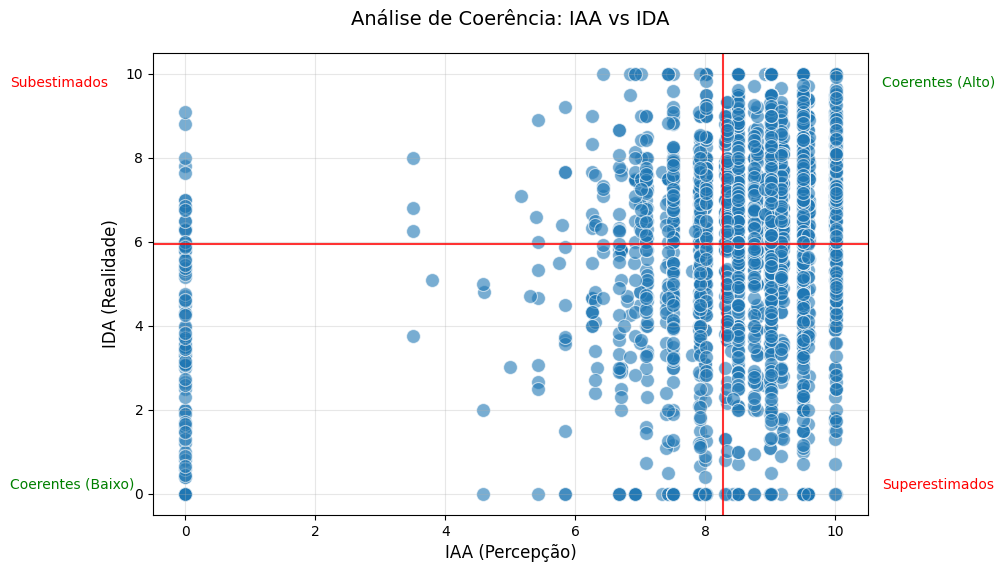

In [41]:
plot_quadrantes('IAA', 'IDA', df_indicadores)

A grande maioria dos pontos está concentrada entre os valores 8 e 10 do IAA. Isso indica que a maioria dos alunos tem uma autopercepção muito elevada, independentemente da nota real.  
  
**Análise dos Quadrantes**  
- Superestimados (Canto Inferior Direito): Há uma densidade altíssima de alunos aqui. Eles avaliaram a si mesmos com notas próximas a 10, mas possuem IDA (desempenho real) variando de 0 a 4. Este grupo está em "cegueira cognitiva", não percebendo suas dificuldades.  
  
- Subestimados (Canto Superior Esquerdo): Note que existem vários pontos no eixo 0 do IAA com notas (IDA) entre 6 e 9. São alunos que não possuem confiança nenhuma em seu potencial, mas apresentam resultados reais excelentes.  
  
- Coerentes (Baixo): Existe uma linha vertical no IAA 0. Muitos alunos se deram nota zero e realmente tiraram notas baixas. Embora o desempenho seja ruim, a percepção deles sobre a própria situação é realista.

Não há coerência substancial. Observa-se um forte viés de sobrevalorização, onde uma parcela significativa de alunos atribui a si mesma a nota máxima de percepção (IAA 10), enquanto seu desempenho real (IDA) ocupa toda a escala de 0 a 10. Além disso, existe um grupo notável de alunos com subestimação severa, que possuem bom desempenho acadêmico apesar de uma autopercepção nula.

### **5. Aspectos psicossociais (IPS): Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?**


In [42]:
df['DELTA_IDA_2021'] = df['IDA_2021'] - df['IDA_2020']
df['DELTA_IDA_2022'] = df['IDA_2022'] - df['IDA_2021']
df['DELTA_IEG_2021'] = df['IEG_2021'] - df['IEG_2020']
df['DELTA_IEG_2022'] = df['IEG_2022'] - df['IEG_2021']

#### Correlação do IPS 2020 x IDA 2021

In [43]:
(df['IPS_2020'].corr(df['DELTA_IDA_2021']) * 100).round(2)

np.float64(1.27)

#### Correlação do IPS 2021 x IDA 2022

In [44]:
(df['IPS_2021'].corr(df['DELTA_IDA_2022']) * 100).round(2)

np.float64(0.47)

#### Correlação do IPS 2020 x IEG 2021

In [45]:
(df['IPS_2020'].corr(df['DELTA_IEG_2021']) * 100).round(2)

np.float64(6.76)

#### Correlação do IPS 2021 x IEG 2022

In [46]:
(df['IPS_2021'].corr(df['DELTA_IEG_2022']) * 100).round(2)

np.float64(-5.26)

As correlações entre $1,27\%$ e $-5,26\%$ indicam que o IPS não é um "motor" que empurra a nota para cima ou para baixo de forma proporcional e constante.

#### Médias por categoria de IPS
  
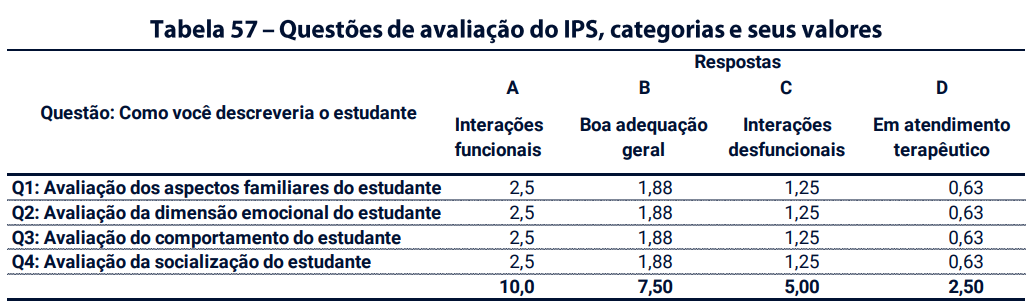

In [47]:
def categoria(df, indicador, ano):
    categ_ipp = [
        (df[f'{indicador}_{ano}'] >= 0) & (df[f'{indicador}_{ano}'] <= 2.5),
        (df[f'{indicador}_{ano}'] > 2.5) & (df[f'{indicador}_{ano}'] <= 5),
        (df[f'{indicador}_{ano}'] > 5) & (df[f'{indicador}_{ano}'] <= 7.5),
        (df[f'{indicador}_{ano}'] > 7.5)
    ]

    valores = [
        'D. Em atendimento terapêutico',
        'C. Interações desfuncionais',
        'B. Boa adequação geral',
        'A. Interações funcionais'
    ]

    df[f'categoria_{indicador}_{ano}'] = np.select(
        condlist=categ_ipp,
        choicelist=valores,
        default='Sem categoria'
    )

In [48]:
categoria(df, 'IPS', 2020)
categoria(df, 'IPS', 2021)

In [49]:
media_IDA_2021_por_categ = df.groupby(by='categoria_IPS_2020')['DELTA_IDA_2021'].mean()
media_IDA_2021_por_categ

categoria_IPS_2020
A. Interações funcionais        -0.861905
B. Boa adequação geral          -1.545030
C. Interações desfuncionais     -1.559574
D. Em atendimento terapêutico   -2.355556
Sem categoria                         NaN
Name: DELTA_IDA_2021, dtype: float64

In [50]:
media_IDA_2022_por_categ = df.groupby(by='categoria_IPS_2021')['DELTA_IDA_2022'].mean()
media_IDA_2022_por_categ

categoria_IPS_2021
A. Interações funcionais         0.875253
B. Boa adequação geral           0.312925
C. Interações desfuncionais      0.606566
D. Em atendimento terapêutico    0.490556
Sem categoria                         NaN
Name: DELTA_IDA_2022, dtype: float64

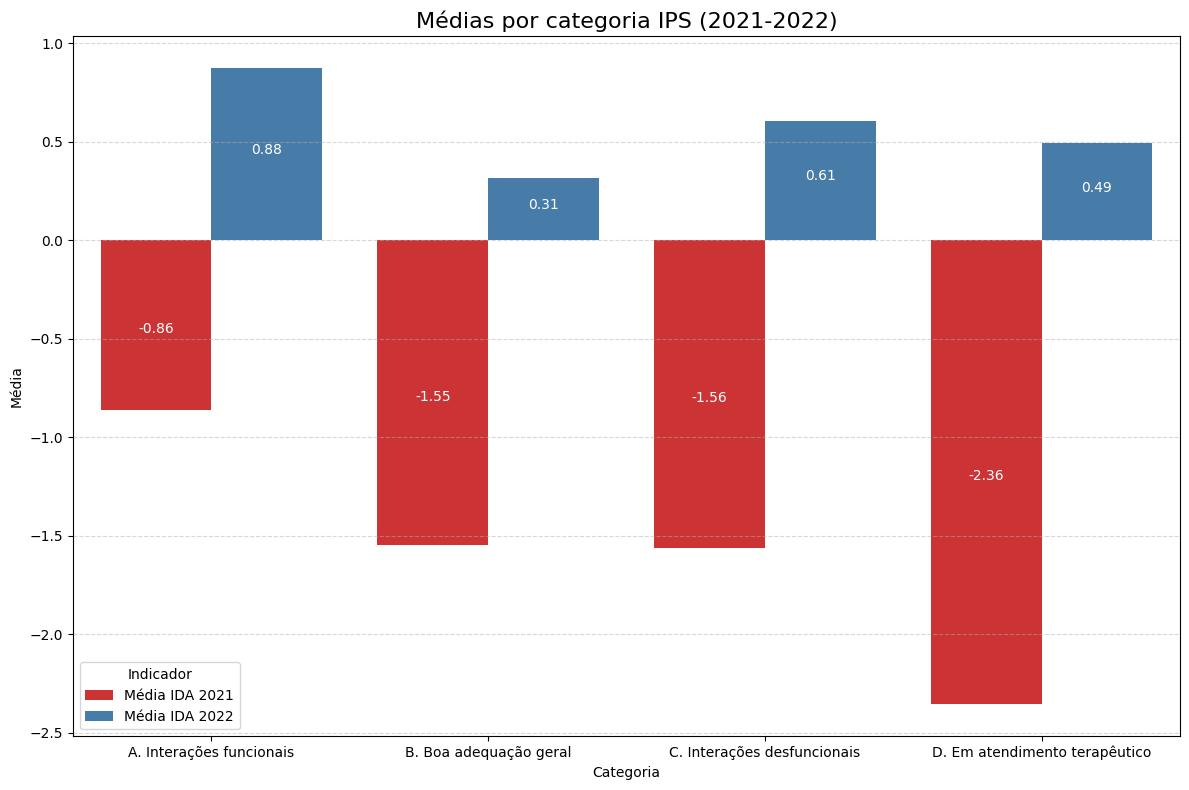

In [51]:
plot_df = pd.DataFrame({
    'media_IDA_2021': media_IDA_2021_por_categ.values,
    'media_IDA_2022': media_IDA_2022_por_categ.values,
}, index=media_IDA_2021_por_categ.index)

plot_df = plot_df.reset_index(names='Categoria')
plot_df = plot_df.melt(id_vars='Categoria', var_name='Indicador_Ano', value_name='Media')
plot_df = plot_df[plot_df['Categoria'] != 'Sem categoria']

legend_map = {
    'media_IDA_2021': 'Média IDA 2021',
    'media_IDA_2022': 'Média IDA 2022'
}
plot_df['Indicador_Ano'] = plot_df['Indicador_Ano'].map(legend_map)

plt.figure(figsize=(12, 8))
ax = sns.barplot(data=plot_df, x='Categoria', y='Media', hue='Indicador_Ano', palette='Set1')

for container in ax.containers:
    ax.bar_label(container, padding=3, label_type='center', fmt='%.2f', color='white')

plt.title('Médias por categoria IPS (2021-2022)', fontsize=16)
plt.xticks(rotation=0)
plt.ylabel('Média')
plt.legend(title='Indicador', loc='lower left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Apesar da baixa correlação o IPS pode funcionar como um indicador de risco.  

Ao olhar para as médias por categoria, o padrão é nítido:

- Efeito de Queda (2020-2021): Alunos na Categoria D (Em atendimento terapêutico) tiveram uma queda de desempenho (-2,35) quase três vezes maior do que os alunos da Categoria A (-0,86).

- Efeito de Recuperação (2021-2022): Quando o cenário foi de melhora, os alunos da Categoria A conseguiram subir sua média em 0,87, enquanto os da Categoria D subiram apenas 0,49.

**Conclusão:** O padrão psicossocial baixo (C e D) antecede quedas mais profundas em momentos de crise e dificulta a recuperação em momentos de melhora. O IPS não é um previsor de nota, mas é um previsor de resiliência.

In [52]:
media_IEG_2021_por_categ = df.groupby(by='categoria_IPS_2020')['DELTA_IEG_2021'].mean()
media_IEG_2021_por_categ

categoria_IPS_2020
A. Interações funcionais        -0.978571
B. Boa adequação geral          -1.536446
C. Interações desfuncionais     -2.059574
D. Em atendimento terapêutico   -1.033333
Sem categoria                         NaN
Name: DELTA_IEG_2021, dtype: float64

In [53]:
media_IEG_2022_por_categ = df.groupby(by='categoria_IPS_2021')['DELTA_IEG_2022'].mean()
media_IEG_2022_por_categ

categoria_IPS_2021
A. Interações funcionais         1.358547
B. Boa adequação geral           0.522217
C. Interações desfuncionais      0.949361
D. Em atendimento terapêutico    0.662179
Sem categoria                         NaN
Name: DELTA_IEG_2022, dtype: float64

Os dados do IEG 2021 mostram que a Categoria C (Interações desfuncionais) teve a maior queda de engajamento (-2,05). Isso sugere que o comportamento social/emocional instável (Categoria C) afeta primeiro a vontade de participar (Engajamento) para depois atingir a nota (Desempenho).

### **6. Aspectos psicopedagógicos (IPP): As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?**

In [54]:
categoria(df, 'IPP',2020)
categoria(df, 'IPP', 2021)
categoria(df, 'IPP', 2022)

In [55]:
categoria_ipp = pd.concat([df['categoria_IPP_2020'], df['categoria_IPP_2021'], df['categoria_IPP_2022']])

In [56]:
df_indicadores = pd.concat([df_indicadores.reset_index(drop=True), categoria_ipp.reset_index(drop=True)], axis=1)

In [57]:
df_indicadores.rename(columns={0: 'CATEG_IPP'}, inplace=True)

In [58]:
df_indicadores['CATEG_IAN'] = df_indicadores['IAN'].replace({10.0: 'Em fase', 5.0: 'Moderada', 2.5: 'Severa'})

#### Correlação IAN x IPP

In [59]:
df_indicadores['IAN'].corr(df_indicadores['IPP'])

np.float64(0.05258247352633372)

O fato de um aluno apresentar defasagem de nível (IAN baixo) não tem poder preditivo sobre o seu estado psicopedagógico (IPP). São dimensões que avaliam aspectos totalmente distintos da realidade do estudante.

In [60]:
matriz_contingencia = pd.crosstab(df_indicadores['CATEG_IPP'], df_indicadores['CATEG_IAN'], dropna=True)
matriz_contingencia

CATEG_IAN,Em fase,Moderada,Severa
CATEG_IPP,,,
A. Interações funcionais,388,442,13
B. Boa adequação geral,422,781,30
C. Interações desfuncionais,29,88,6
D. Em atendimento terapêutico,45,31,0


In [61]:
matriz_percentual = (pd.crosstab(df_indicadores['CATEG_IPP'], df_indicadores['CATEG_IAN'], normalize='all') * 100).round(2)
matriz_percentual

CATEG_IAN,Em fase,Moderada,Severa
CATEG_IPP,,,
A. Interações funcionais,17.05,19.43,0.57
B. Boa adequação geral,18.55,34.33,1.32
C. Interações desfuncionais,1.27,3.87,0.26
D. Em atendimento terapêutico,1.98,1.36,0.00


A matriz revela que a maioria dos alunos com atraso escolar possui, na verdade, um ótimo perfil psicopedagógico.

**O "Potencial Oculto" na Defasagem Moderada:** Dos alunos classificados com defasagem "Moderada" no IAN, a grande maioria está nas categorias A (442 alunos) e B (781 alunos) do IPP. Isso representa aproximadamente 53,7% da amostra total (19,43% + 34,33%). Ou seja, o IPP contradiz a defasagem ao mostrar que esses alunos possuem "Interações Funcionais" ou "Boa Adequação Geral".

**Baixa Concordância na Defasagem Severa:** No grupo de defasagem "Severa", nenhum aluno (0,00%) foi classificado como necessitando de "Atendimento Terapêutico" (IPP D). Pelo contrário, a maioria desses alunos severamente defasados academicamente possui perfis de "Interações Funcionais" ou "Boa Adequação" (Categorias A e B).

**Concordância na "Em Fase":** Apenas no grupo "Em fase" nota-se um equilíbrio, onde 388 alunos (17,05%) e 422 alunos (18,55%) confirmam a adequação acadêmica com uma boa adequação psicopedagógica.

Os dados demonstram que o IPP **contradiz** a defasagem do IAN. A correlação desprezível (0,052) e a alta concentração de alunos com defasagem acadêmica (Moderada/Severa) que apresentam indicadores psicopedagógicos de alta funcionalidade (Categorias A e B) sugerem que o atraso escolar não está vinculado a impedimentos cognitivos, comportamentais ou sociais mensurados pelo IPP. Isso indica que a defasagem medida pelo IAN provavelmente decorre de fatores externos ao desenvolvimento individual do aluno, como histórico de acesso escolar ou vulnerabilidades socioeconômicas anteriores.

### **7. Ponto de virada (IPV): Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?**

In [62]:
def categoria_IPV(df, ano):
    categ_ipp = [
        (df[f'IPV_{ano}'] >= 0) & (df[f'IPV_{ano}'] <= 2.5),
        (df[f'IPV_{ano}'] > 2.5) & (df[f'IPV_{ano}'] <= 5),
        (df[f'IPV_{ano}'] > 5) & (df[f'IPV_{ano}'] <= 7.5),
        (df[f'IPV_{ano}'] > 7.5)
    ]

    valores = [
        'D. Apresenta dificuldades',
        'C. Desempenho insuficiente',
        'B. Desempenho suficiente',
        'A. Desempenho positivo'
    ]

    df[f'categoria_IPV_{ano}'] = np.select(
        condlist=categ_ipp,
        choicelist=valores,
        default='Sem categoria'
    )

In [63]:
categoria_IPV(df, 2020)
categoria_IPV(df, 2021)
categoria_IPV(df, 2022)

In [64]:
categoria_IPV = pd.concat([df['categoria_IPV_2020'], df['categoria_IPV_2021'], df['categoria_IPV_2022']])

In [65]:
df_indicadores = pd.concat([df_indicadores.reset_index(drop=True), categoria_IPV.reset_index(drop=True)], axis=1)

In [66]:
df_indicadores.rename(columns={0: 'CATEG_IPV'}, inplace=True)

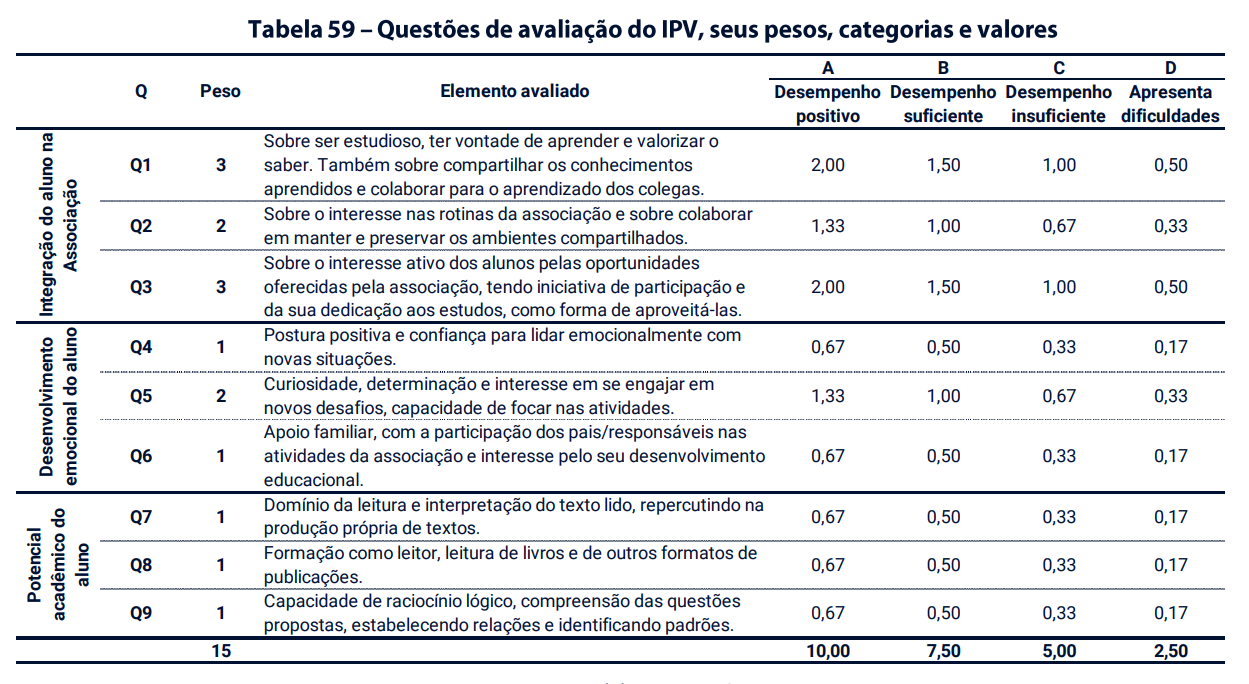

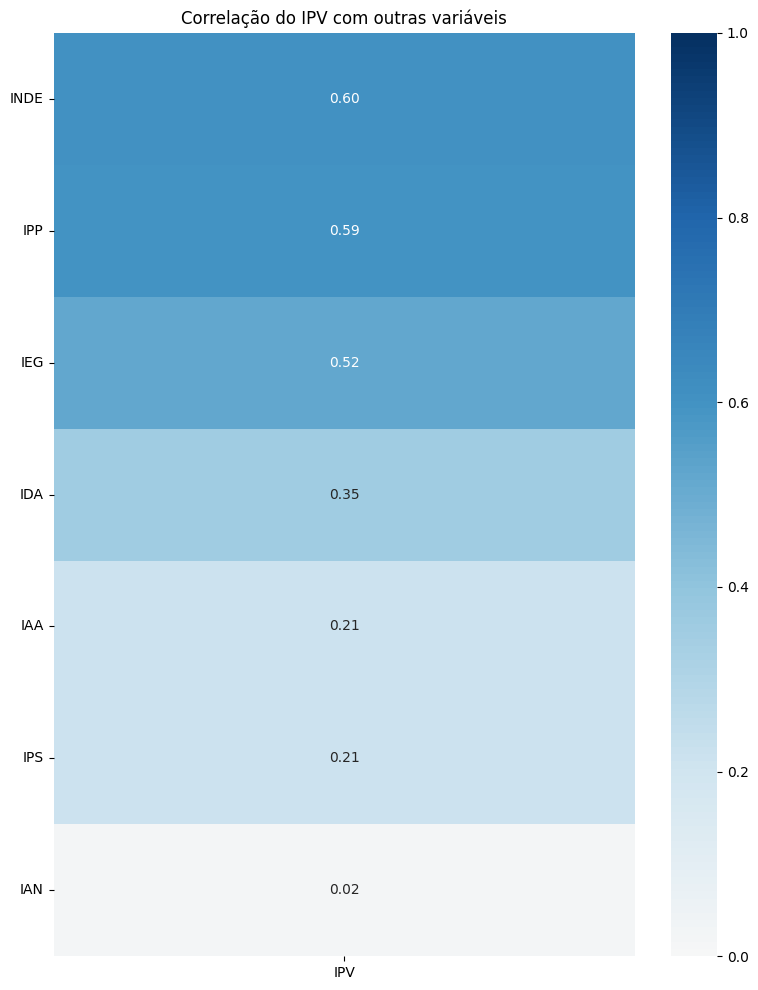

In [67]:
cols_numeric = df_indicadores.select_dtypes(include=['number']).columns

corr_ipv = df_indicadores[cols_numeric].corr()['IPV'].sort_values(ascending=False)

plt.figure(figsize=(8, 10))
sns.heatmap(
    corr_ipv.drop('IPV').to_frame(),
    annot=True, 
    cmap='RdBu', 
    center=0,
    fmt='.2f',
    vmin=0.0,
    vmax=1.0
)
plt.title('Correlação do IPV com outras variáveis')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

A análise de correlação identifica quais indicadores caminham juntos com o Ponto de Virada.

- **Conexão Primária:** O INDE apresenta a maior correlação isolada ($0,60$), seguido pelo IPP ($0,59$) e IEG ($0,52$).

- **Conexão Secundária:** O IDA (Aprendizagem) mantém uma associação moderada ($0,35$).

- **Conexão de Percepção:** O IAA (Autoavaliação) e o IPS (Social) têm correlações idênticas ($0,21$), indicando uma influência mais periférica.

- **Irrelevância Estatística:** O IAN (Adequação de Nível) confirma-se como um fator que não impacta a transição para o Ponto de Virada ($0,02$).

#### Regressão linear

In [68]:
def resumo_regressao_multipla(df, lista_independentes, dependente):
    # 1. Preparação: garante que estamos usando apenas as colunas necessárias e sem NaNs
    colunas = lista_independentes + [dependente]
    df_limpo = df[colunas].dropna()
    
    X = df_limpo[lista_independentes]
    X = sm.add_constant(X) # Adiciona o intercepto
    y = df_limpo[dependente]
    
    # 2. Ajuste do Modelo
    modelo = sm.OLS(y, X).fit()
    
    # 3. Relatório Executivo
    print(f"ANÁLISE DE IMPACTO MULTIVARIÁVEL -> {dependente}")
    print(f"Poder de Explicação Global (R² Ajustado): {modelo.rsquared_adj:.2%}")
    print("-" * 60)
    print(f"{'Indicador':<15} | {'Impacto (Coef)':<15} | {'Confiança (P-Value)':<20}")
    print("-" * 60)
    
    # Loop pelos coeficientes (pulando a constante)
    for var in lista_independentes:
        coef = modelo.params[var]
        p_val = modelo.pvalues[var]
        status = "Significativo" if p_val < 0.05 else "Não Signif."
        
        print(f"{var:<15} | {coef:>15.4f} | {p_val:>8.4f} ({status})")
    
    print("-" * 60)
    return modelo

In [71]:
indicadores = ['IEG', 'IDA', 'IPS', 'IPP', 'IAA', 'INDE']
resumo_regressao_multipla(df_indicadores, indicadores, 'IPV')

ANÁLISE DE IMPACTO MULTIVARIÁVEL -> IPV
Poder de Explicação Global (R² Ajustado): 59.12%
------------------------------------------------------------
Indicador       | Impacto (Coef)  | Confiança (P-Value) 
------------------------------------------------------------
IEG             |          0.1017 |   0.0000 (Significativo)
IDA             |         -0.0879 |   0.0000 (Significativo)
IPS             |         -0.0258 |   0.1409 (Não Signif.)
IPP             |          0.4415 |   0.0000 (Significativo)
IAA             |         -0.0307 |   0.0130 (Significativo)
INDE            |          0.6450 |   0.0000 (Significativo)
------------------------------------------------------------


Ao isolarmos o efeito de cada variável simultaneamente, o modelo agora explica 59,12% da variação do IPV (R² Ajustado). Esta é uma métrica de alta confiança para decisões estratégicas.

| Indicador | Impacto (Coef) | Confiança (P-Value)        | Interpretação |
|----------|----------------|----------------------------|---------------|
| INDE     | 0,6450         | 0,0000 (Signif.)           | O Principal Motor: É a variável que mais “puxa” o aluno para o Ponto de Virada. |
| IPP      | 0,4415         | 0,0000 (Signif.)           | Base Pedagógica: A visão técnica da equipe é o segundo maior pilar. |
| IEG      | 0,1017         | 0,0000 (Signif.)           | Catalisador: O engajamento ativo continua sendo um fator positivo essencial. |
| IAA      | -0,0307        | 0,0130 (Signif.)           | Percepção Externa: O IPV valida mais a observação técnica do que a autoavaliação do aluno. |
| IDA      | -0,0879        | 0,0000 (Signif.)           | Maturidade vs Nota: O IPV foca na mudança de postura, não apenas em notas altas. |
| IPS      | -0,0258        | 0,1409 (Não Signif.)       | Ruído: O aspecto social isolado não é um preditor confiável para o IPV. |

**Conclusões:**

- **O Triângulo do Sucesso (INDE, IPP, IEG):** O Ponto de Virada é atingido quando há uma combinação de desenvolvimento global (INDE), suporte pedagógico (IPP) e engajamento do aluno (IEG). Estes três, somados, são os verdadeiros responsáveis pelo sucesso estatístico do modelo.

- **Comportamentos-Chave (Tabela 59):** O impacto expressivo do IPP e IEG sugere que os comportamentos de maior influência são a vontade de aprender e valorizar o saber (Q1) e o interesse ativo e iniciativa (Q3).

### **8. Multidimensionalidade dos indicadores: Quais combinações de indicadores (IDA + IEG + IPS + IPP) melhor explicam o desempenho global do aluno (INDE)?**


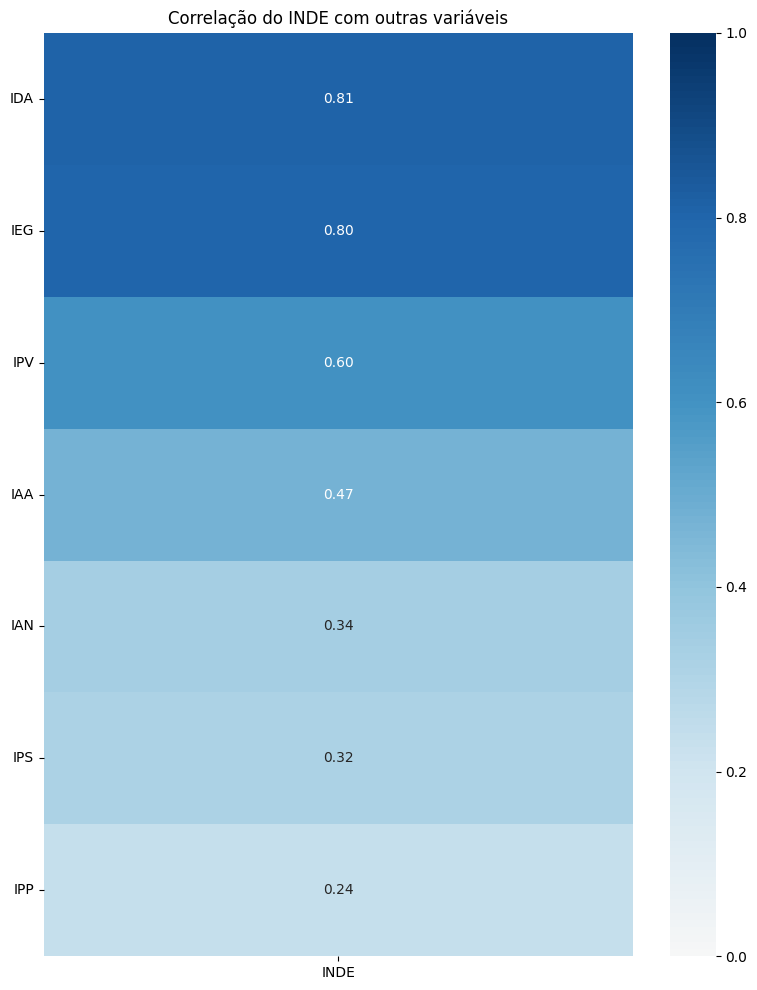

In [70]:
cols_numeric = df_indicadores.select_dtypes(include=['number']).columns

corr_ipv = df_indicadores[cols_numeric].corr()['INDE'].sort_values(ascending=False)

plt.figure(figsize=(8, 10))
sns.heatmap(
    corr_ipv.drop('INDE').to_frame(),
    annot=True, 
    cmap='RdBu', 
    center=0,
    fmt='.2f',
    vmin=0.0,
    vmax=1.0
)
plt.title('Correlação do INDE com outras variáveis')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [73]:
indicadores = ['IEG', 'IDA', 'IPS', 'IPP']
resumo_regressao_multipla(df_indicadores, indicadores, 'INDE')

ANÁLISE DE IMPACTO MULTIVARIÁVEL -> INDE
Poder de Explicação Global (R² Ajustado): 88.47%
------------------------------------------------------------
Indicador       | Impacto (Coef)  | Confiança (P-Value) 
------------------------------------------------------------
IEG             |          0.2560 |   0.0000 (Significativo)
IDA             |          0.2574 |   0.0000 (Significativo)
IPS             |          0.1423 |   0.0000 (Significativo)
IPP             |          0.1269 |   0.0000 (Significativo)
------------------------------------------------------------


Quase 90% de tudo o que compõe a nota final do aluno (INDE) é explicado por esses quatro pilares. Apenas ~11% dependem de fatores externos não mapeados no modelo.

- **Bloco de Alta Influência (Os Motores) IDA (0.2574) e IEG (0.2560):** Observe que os pesos são quase idênticos. Isso prova que, para o INDE, o desempenho acadêmico (nota) é tão importante quanto o engajamento (esforço/presença). Um aluno não consegue um INDE alto apenas sendo "genial" (IDA) se não for engajado (IEG), e vice-versa.

- **Bloco de Apoio (Os Diferenciais) IPS (0.1423) e IPP (0.1269):** Eles têm um peso menor (cerca de metade do impacto do IDA/IEG), mas ainda são fundamentais para "refinar" a nota global. O IPP, que no heatmap parecia fraco (0.24), aqui se mostra um componente sólido quando somado aos outros.

**Conclusão:** A melhor explicação para o desempenho global (INDE) não reside em um único indicador, mas na sinergia equilibrada entre o desempenho acadêmico (IDA) e o engajamento estudantil (IEG), que juntos detêm o maior peso na composição da nota. A análise multivariada prova que o modelo é altamente eficaz, com um poder de explicação de 88,47%, onde os aspectos socioemocionais e psicopedagógicos (IPS e IPP) atuam como componentes complementares indispensáveis para a visão integral do aluno.

### **9. Previsão de risco com Machine Learning: Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem? Construa um modelo preditivo que mostre uma probabilidade do aluno ou aluna entrar em risco de defasagem.**

In [582]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

In [583]:
def engenharia_features(df):
    # 1. Indicadores de Desequilíbrio
    df['GAP_APRENDIZADO'] = df['IPP'] - df['IDA'] # Potencial vs Entrega
    
    # 2. Score Psicossocial Consolidado
    df['SUPORTE_TOTAL'] = (df['IPS'] + df['IPP'] + df['IAA']) / 3
    
    # 3. Flags de Risco Crítico (Baseado nos padrões da Passos Mágicos)
    # Risco se Engajamento E Ponto de Virada estão baixos
    df['RISCO_POSTURA'] = ((df['IEG'] < 7) & (df['IPV'] < 7)).astype(int)
    
    # 4. Normalização por grupo (se tiver a coluna de nível/turma)
    if 'NIVEL' in df.columns:
        df['RELATIVO_IEG'] = df['IEG'] / df.groupby('NIVEL')['IEG'].transform('mean')
    
    return df

In [584]:
df_indicadores = engenharia_features(df_indicadores)

In [585]:
features = ['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 
            'GAP_APRENDIZADO', 'SUPORTE_TOTAL', 'RISCO_POSTURA']
df_modelo = df_indicadores[features + ['IAN']].dropna()
X = df_modelo[features]
y = df_modelo['IAN'].apply(lambda x: 1 if x < 10.0 else 0)

In [586]:
y.value_counts(normalize=True) * 100

IAN
1    61.142857
0    38.857143
Name: proportion, dtype: float64

In [587]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [588]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [589]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

In [590]:
gb = GradientBoostingClassifier(random_state=42,
                                learning_rate=0.01,
                                max_depth=3,
                                n_estimators=100,
                                subsample=0.8)

In [591]:
# param_grid = {
#     'learning_rate': [0.01, 0.05, 0.1],
#     'n_estimators': [100, 200, 300, 400, 500],
#     'max_depth': [3, 4, 5, 6],
#     'subsample': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
# }

In [592]:
# grid_search = GridSearchCV(
#     estimator=gb, 
#     param_grid=param_grid, 
#     scoring='roc_auc', 
#     cv=5, 
#     n_jobs=-1
# )

In [593]:
# grid_search.fit(X_train_scaled, y_train)

In [594]:
# best_model = grid_search.best_estimator_

In [595]:
# best_model.fit(X_train_scaled, y_train)

In [596]:
# print(grid_search.best_params_)
# {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

In [597]:
gb.fit(X_train_res, y_train_res)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.01
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [598]:
probabilidades = gb.predict_proba(X_test_scaled)[:, 1]
print(f"ROC AUC Score: {roc_auc_score(y_test, probabilidades):.4f}")

ROC AUC Score: 0.6425


In [599]:
y_pred = gb.predict(X_test_scaled)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")

Accuracy Score: 0.5934


In [600]:
importances = pd.Series(gb.feature_importances_, index=features).sort_values(ascending=False)
print("Indicadores que mais influenciam o risco:") 
print(importances)

Indicadores que mais influenciam o risco:
IEG                0.239730
IPP                0.224251
IPV                0.144238
IAA                0.135352
GAP_APRENDIZADO    0.110894
IDA                0.091681
SUPORTE_TOTAL      0.030508
IPS                0.023331
RISCO_POSTURA      0.000016
dtype: float64
